# Epithelial sub-clustering (3-layer pipeline)

This notebook continues from `04_cell_type_annotation.ipynb`: it subsets the `Epithelial` compartment (from `lv1_annotation`), re-clusters it at finer resolution, and annotates the resulting sub-clusters using the same three complementary layers of evidence.

1. **Canonical/known marker annotation** — score each sub-cluster against the epithelial-relevant curated marker sets.
2. **DEG-driven manual annotation** — pull top DEGs per sub-cluster, cross-check against literature/Protein Atlas, and record a manual label.
3. **Functional enrichment (GO/KEGG/Reactome)** — run over-representation analysis on sub-cluster DEGs to support/refine the label.

Outputs are written to `results/xenium_5k/annotation/subclustering/epithelial/`.

In [1]:
import os
import re
import warnings
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import spatialdata as sd
import spatialdata_plot
import gseapy as gp

%load_ext autoreload
%autoreload 2

warnings.filterwarnings('ignore')

GROUP = 'Epithelial'
annot_dir = '../../results/xenium_5k/annotation/subclustering/epithelial'
os.makedirs(annot_dir, exist_ok=True)

/home/duydao/micromamba/envs/spatial_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load the lv1-annotated object saved at the end of notebook 04 and subset to this compartment
sdata = sd.read_zarr('../../data/spatialdata/xenium_prime_5k_lv1_annotated.zarr')
adata_full = sdata['table']
adata = adata_full[adata_full.obs['lv1_annotation'] == GROUP].copy()
print(f'{adata.n_obs} cells in the {GROUP} compartment (of {adata_full.n_obs} total)')

no parent found for <ome_zarr.reader.Label object at 0x7b16f02d4950>: None
no parent found for <ome_zarr.reader.Label object at 0x7b16f0112ba0>: None


68449 cells in the Epithelial compartment (of 266179 total)


## Sub-clustering

Fresh HVG -> PCA -> neighbors -> Leiden on just this compartment's cells (mirrors `02_Xenium_5k_downstream_qc_filter_clustering_python.ipynb`'s parameters). Bump `sub_resolution` if sub-types still look merged.

In [3]:
sub_resolution = 0.5

sc.pp.highly_variable_genes(adata, flavor='seurat_v3', n_top_genes=2000)
sc.pp.pca(adata, n_comps=30)
sc.pp.neighbors(adata, metric='cosine')
sc.tl.leiden(adata, key_added='sub_leiden', flavor='igraph', n_iterations=-1, resolution=sub_resolution)
sc.tl.umap(adata)

adata.obs['sub_leiden'] = adata.obs['sub_leiden'].astype('category')
sub_clusters = adata.obs['sub_leiden'].cat.categories.tolist()
print(f'{len(sub_clusters)} sub-clusters, {adata.n_obs} cells')

12 sub-clusters, 68449 cells


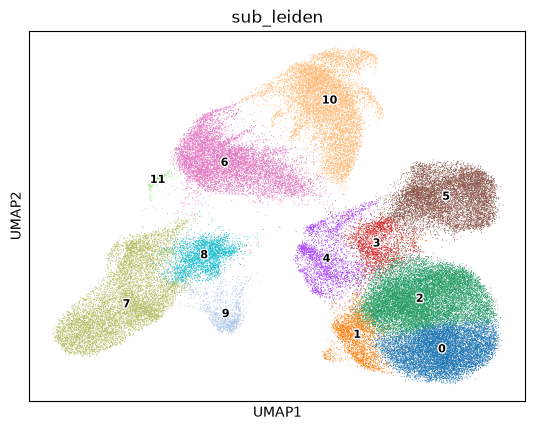

In [28]:
# fixed palette shared with the spatial cluster plot below
cluster_colors = dict(zip(sub_clusters, sc.pl.palettes.default_20 if len(sub_clusters) <= 20 else sc.pl.palettes.default_102))
adata.uns['sub_leiden_colors'] = [cluster_colors[c] for c in sub_clusters]

sc.pl.umap(adata, color='sub_leiden', legend_loc='on data', legend_fontsize=8, legend_fontoutline=2)

## Layer 1 — Canonical/known marker annotation

Reuses the curated marker dict from `04_cell_type_annotation.ipynb`, filtered down to the signatures relevant to this compartment (plus `Proliferating`, useful in every compartment).

In [5]:
canonical_markers_all = {
    'Epithelial_AT1': ['AGER', 'PDPN', 'CAV1'],
    'Epithelial_AT2': ['LAMP3', 'ABCA3', 'SLC34A2', 'TCIM', 'SFTPC', 'SFTPB', 'SFTPA1', 'NAPSA'],
    'Epithelial_Airway_Ciliated': ['FOXJ1', 'TPPP3', 'PIFO'],
    'Epithelial_Airway_Club_Secretory': ['SCGB1A1', 'SCGB3A1', 'MUC5B'],
    'Epithelial_Tumor_Malignant': ['EPCAM', 'KRT8', 'KRT18', 'KRT19'],
    'Epithelial_LUAD (Adenocarcinoma)': ['NAPSA', 'NKX2-1', 'SFTPC', 'SFTPB', 'MUC5AC', 'MUC5B', 'KRT7'],
    'Lymphoid_T_cell_CD4+': ['CD3D', 'CD3E', 'CD2', 'TRAC', 'CD4'],
    'Lymphoid_T_cell_CD8+': ['CD3D', 'CD3E', 'CD2', 'TRAC', 'CD8A', 'CD8B'],
    'Lymphoid_NK_cell': ['NKG7', 'GNLY', 'KLRD1'],
    'Lymphoid_B_cell': ['MS4A1', 'CD79A', 'CD79B'],
    'Lymphoid_Plasma_cell': ['MZB1', 'JCHAIN', 'IGHG1'],
    'Myeloid_Macrophage_M1': ['CD68', 'CD86', 'CD80', 'IL1B', 'TNF', 'NOS2', 'IL6', 'IL12A'],
    'Myeloid_Macrophage_M2': ['CD68', 'CD163', 'MRC1', 'CCL18', 'MSR1', 'IL10', 'TGM2', 'TGFB1'],
    'Myeloid_Monocyte': ['CD14', 'CD74', 'LYZ', 'ITGAM'],
    'Myeloid_Neutrophil': ['FCGR3B', 'FMLP2', 'CEBPE', 'MPO', 'ELANE', 'AZU1', 'LILRA5', 'MXD1', 'CSF3R'],
    'Myeloid_Dendritic_cell': ['CD74', 'FCER1A', 'CST3', 'AIF1'],
    'Myeloid_Mast_cell': ['TPSAB1', 'TPSB2', 'CPA3', 'CMA1', 'KIT'],
    'Stromal_Fibroblast': ['COL1A1', 'COL1A2', 'DCN', 'PDGFRA'],
    'Stromal_Smooth_muscle/Pericyte': ['ACTA2', 'MYH11', 'PDGFRB'],
    'Vessels_EC': ['PECAM1', 'VWF', 'CLDN5'],
    'Proliferating': ['MKI67', 'TOP2A', 'PCNA', 'CDK1', 'UBE2C', 'BIRC5', 'CCNB1', 'CCNB2', 'MCM2', 'MCM5'],
}

# Keep only the marker sets relevant to this compartment (+ Proliferating)
group_prefixes = ('Epithelial_',)
extra_keys = {'Proliferating'}
canonical_markers = {
    k: v for k, v in canonical_markers_all.items()
    if k.startswith(group_prefixes) or k in extra_keys
}

# Keep only genes present in the panel, and drop cell types left with no genes
canonical_markers = {
    cell_type: [g for g in genes if g in adata.var_names]
    for cell_type, genes in canonical_markers.items()
}
missing = {k: v for k, v in canonical_markers.items() if len(v) == 0}
if missing:
    print('Cell types with no marker genes found in panel (dropped):', list(missing.keys()))
canonical_markers = {k: v for k, v in canonical_markers.items() if len(v) > 0}
canonical_markers

{'Epithelial_AT1': ['AGER', 'PDPN'],
 'Epithelial_AT2': ['LAMP3', 'ABCA3', 'TCIM'],
 'Epithelial_Airway_Ciliated': ['FOXJ1', 'TPPP3'],
 'Epithelial_Airway_Club_Secretory': ['MUC5B'],
 'Epithelial_Tumor_Malignant': ['EPCAM'],
 'Epithelial_LUAD (Adenocarcinoma)': ['NKX2-1', 'MUC5AC', 'MUC5B'],
 'Proliferating': ['MKI67',
  'TOP2A',
  'PCNA',
  'CDK1',
  'UBE2C',
  'BIRC5',
  'CCNB1',
  'CCNB2',
  'MCM2',
  'MCM5']}

In [6]:
adata.obs.drop(columns=[c for c in adata.obs.columns if c.startswith('score_')], inplace=True, errors='ignore')
for cell_type, genes in canonical_markers.items():
    sc.tl.score_genes(adata, gene_list=genes, score_name=f'score_{cell_type}', layer='lognorm')

score_cols = [f'score_{ct}' for ct in canonical_markers]
cluster_scores = adata.obs.groupby('sub_leiden', observed=True)[score_cols].mean()
cluster_scores.columns = list(canonical_markers.keys())
cluster_scores

,Epithelial_AT1,Epithelial_AT2,Epithelial_Airway_Ciliated,Epithelial_Airway_Club_Secretory,Epithelial_Tumor_Malignant,Epithelial_LUAD (Adenocarcinoma),Proliferating
sub_leiden,,,,,,,
0,-0.143729,-0.123981,-0.086869,-0.089967,0.012295,0.111937,-0.009074
1,-0.122676,-0.100571,-0.082775,-0.097114,-0.064746,0.034582,-0.004734
2,-0.139228,-0.150080,-0.078314,-0.085903,0.057090,0.034194,-0.004235
3,-0.097187,-0.088174,-0.063732,-0.064780,-0.031445,-0.009100,-0.001414
4,-0.130802,-0.124933,-0.061029,-0.086668,0.037695,0.002405,0.109205
5,-0.147634,-0.112904,-0.091527,-0.097513,0.105468,0.050173,-0.004911
6,-0.007329,0.591675,-0.052050,-0.071720,-0.203297,0.076283,-0.010462
7,-0.115840,-0.094746,0.485298,0.613782,-0.115364,0.260332,-0.004977
8,-0.083695,-0.102473,0.044859,0.034830,-0.320509,0.031363,-0.006783


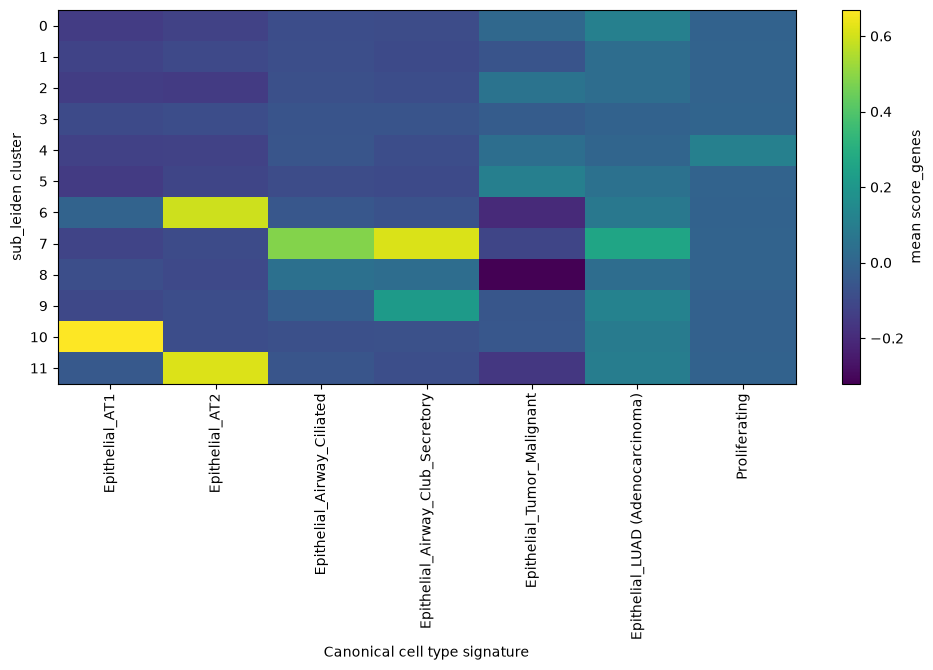

In [7]:
fig, ax = plt.subplots(figsize=(10, 0.4 * len(cluster_scores) + 2))
im = ax.imshow(cluster_scores.values, cmap='viridis', aspect='auto')
ax.set_xticks(range(len(cluster_scores.columns)))
ax.set_xticklabels(cluster_scores.columns, rotation=90)
ax.set_yticks(range(len(cluster_scores)))
ax.set_yticklabels(cluster_scores.index)
ax.set_xlabel('Canonical cell type signature')
ax.set_ylabel('sub_leiden cluster')
fig.colorbar(im, ax=ax, label='mean score_genes')
plt.tight_layout()

In [8]:
layer1_annotation = pd.DataFrame({
    'cluster': cluster_scores.index,
    'canonical_label': cluster_scores.idxmax(axis=1).values,
    'canonical_score': cluster_scores.max(axis=1).values,
}).reset_index(drop=True)
layer1_annotation

,cluster,canonical_label,canonical_score
0,0,Epithelial_LUAD (Adenocarcinoma),0.111937
1,1,Epithelial_LUAD (Adenocarcinoma),0.034582
2,2,Epithelial_Tumor_Malignant,0.057090
3,3,Proliferating,-0.001414
4,4,Proliferating,0.109205
5,5,Epithelial_Tumor_Malignant,0.105468
6,6,Epithelial_AT2,0.591675
7,7,Epithelial_Airway_Club_Secretory,0.613782
8,8,Epithelial_Airway_Ciliated,0.044859
9,9,Epithelial_Airway_Club_Secretory,0.218664


In [9]:
def plot_subcluster_score(adata, sdata, cell_type_name, figsize=(12.8, 9.6)):
    """Plot a sub-cluster marker score spatially by projecting it onto the full sdata table (in-memory only)."""
    score_col = f'score_{cell_type_name}'
    if score_col not in adata.obs.columns:
        print(f"Score column '{score_col}' not found in adata.obs")
        print('Available score columns:', [c for c in adata.obs.columns if c.startswith('score_')])
        return

    plot_col = re.sub(r'[^A-Za-z0-9_.-]', '_', score_col)
    full_table = sdata.tables['table']
    full_table.obs[plot_col] = adata.obs[score_col].reindex(full_table.obs.index)

    sc.pl.umap(adata, color=score_col, cmap='viridis')
    sdata.pl.render_shapes('cell_boundaries', color=plot_col, cmap='viridis').pl.show(figsize=figsize)

# Example usage:
# plot_subcluster_score(adata, sdata, 'Epithelial_AT2')

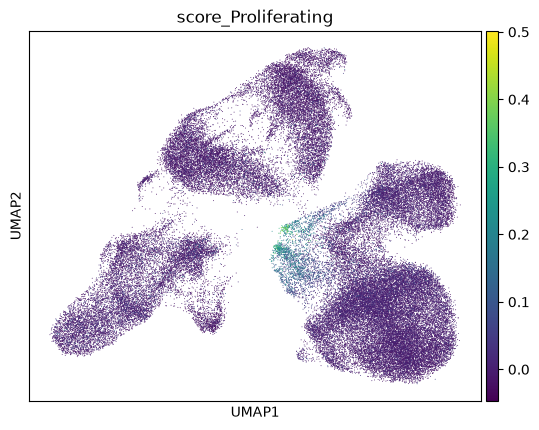

WARNING  render_shapes: Found 209879 NaN values in color data. These observations will be colored with the         
         'na_color'.                                                                                               


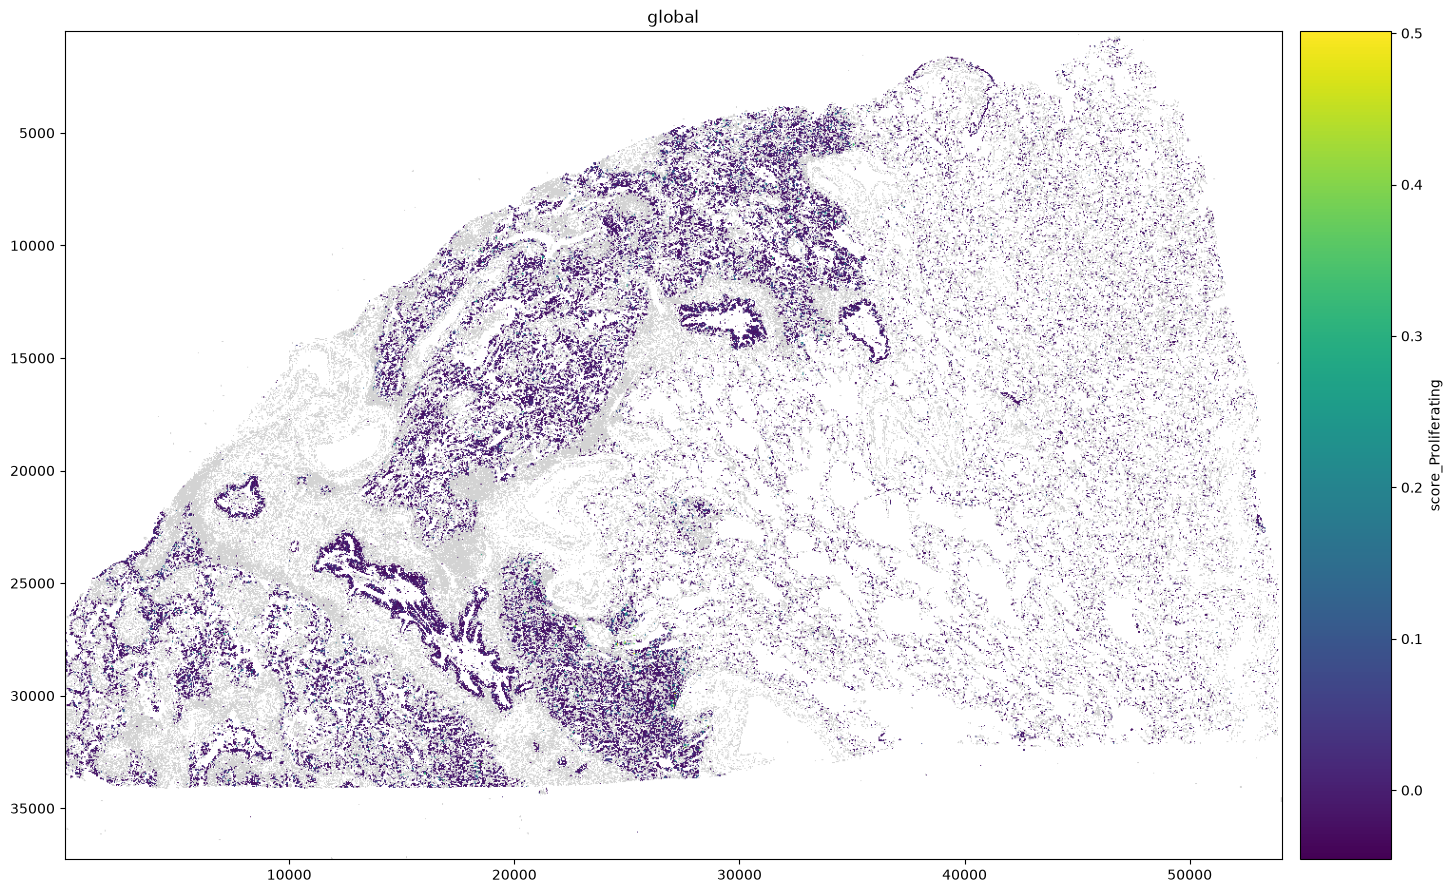

In [10]:
plot_subcluster_score(adata, sdata, 'Proliferating')

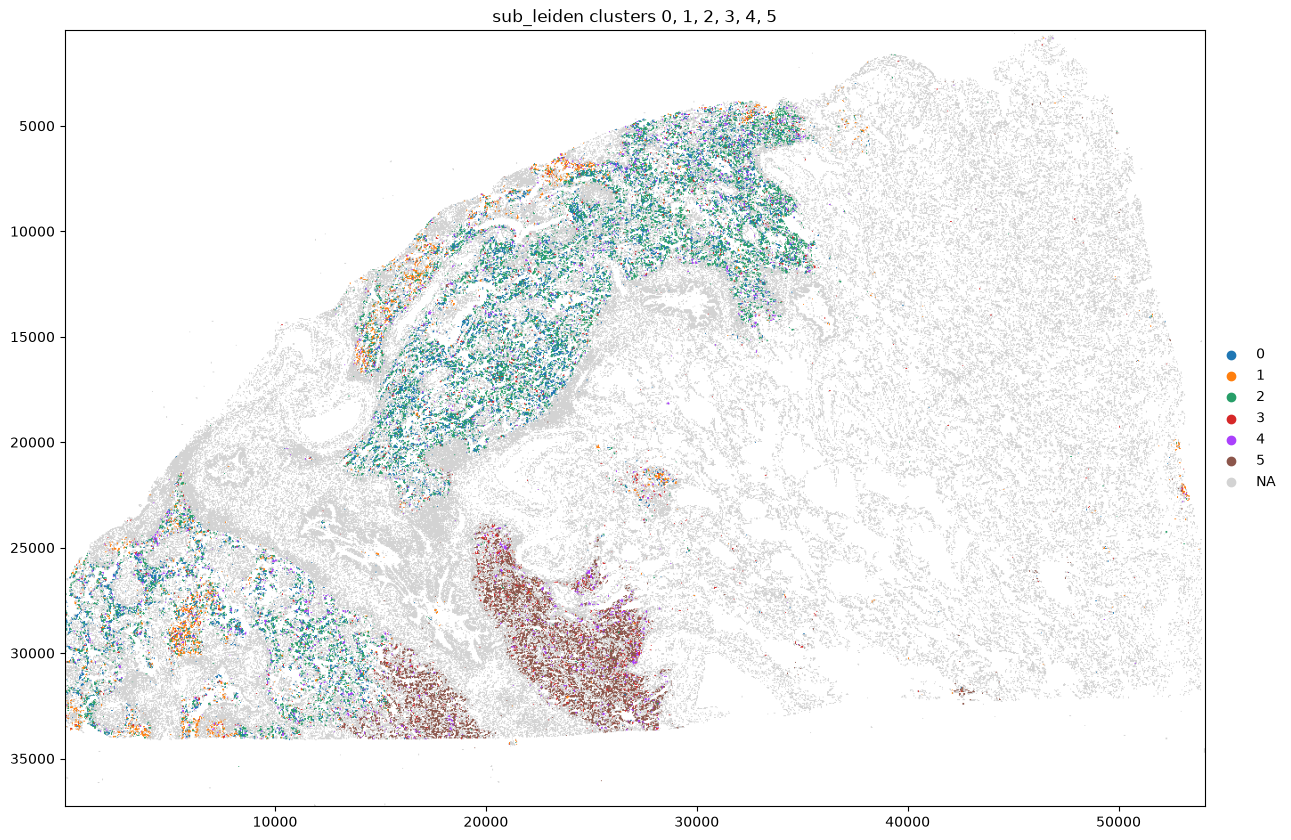

In [29]:
clusters_to_plot = ['0', '1', '2', '3', '4', '5']

plot_col = 'sub_leiden_subset'
full_table = sdata.tables['table']
sub_leiden_masked = adata.obs['sub_leiden'].where(adata.obs['sub_leiden'].isin(clusters_to_plot))
full_table.obs[plot_col] = sub_leiden_masked.reindex(full_table.obs.index)

sdata.tables['table'].obs['region'] = 'cell_boundaries'
sdata.set_table_annotates_spatialelement('table', region='cell_boundaries')
sdata.pl.render_shapes('cell_boundaries', color=plot_col, palette=cluster_colors).pl.show(
    figsize=(12.8, 9.6), title=f"sub_leiden clusters {', '.join(clusters_to_plot)}"
)

### Zoom-in Visualization

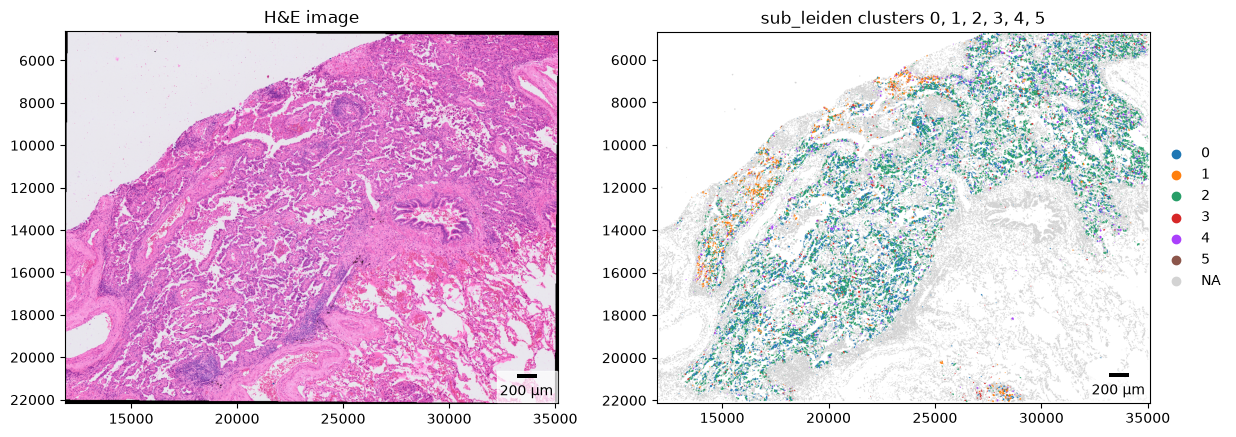

In [32]:
from spatialdata import bounding_box_query
from matplotlib_scalebar.scalebar import ScaleBar

# TODO: set to the region of interest (pixel coordinates)
min_x, max_x = 12_000, 35_000
min_y, max_y = 4800, 22_000

cropped_sdata = bounding_box_query(
    sdata,
    min_coordinate=[min_x, min_y],
    max_coordinate=[max_x, max_y],
    axes=("x", "y"),
    target_coordinate_system="global",
)

axes = plt.subplots(1, 2, figsize=(14, 7))[1].flatten()

cropped_sdata.pl.render_images("he_image").pl.show(ax=axes[0], title="H&E image", coordinate_systems="global")
cropped_sdata.pl.render_shapes("cell_boundaries", color=plot_col, palette=cluster_colors).pl.show(
    ax=axes[1], title=f"sub_leiden clusters {', '.join(clusters_to_plot)}", coordinate_systems="global"
)

pixel_size_in_microns = 0.2125

for ax in axes:
    scalebar = ScaleBar(
        dx=pixel_size_in_microns,
        units="um",
        location="lower right",
        color="black",
        box_color="white",
        box_alpha=0.7,
        length_fraction=0.1,
    )
    ax.add_artist(scalebar)

### Plot full clusters

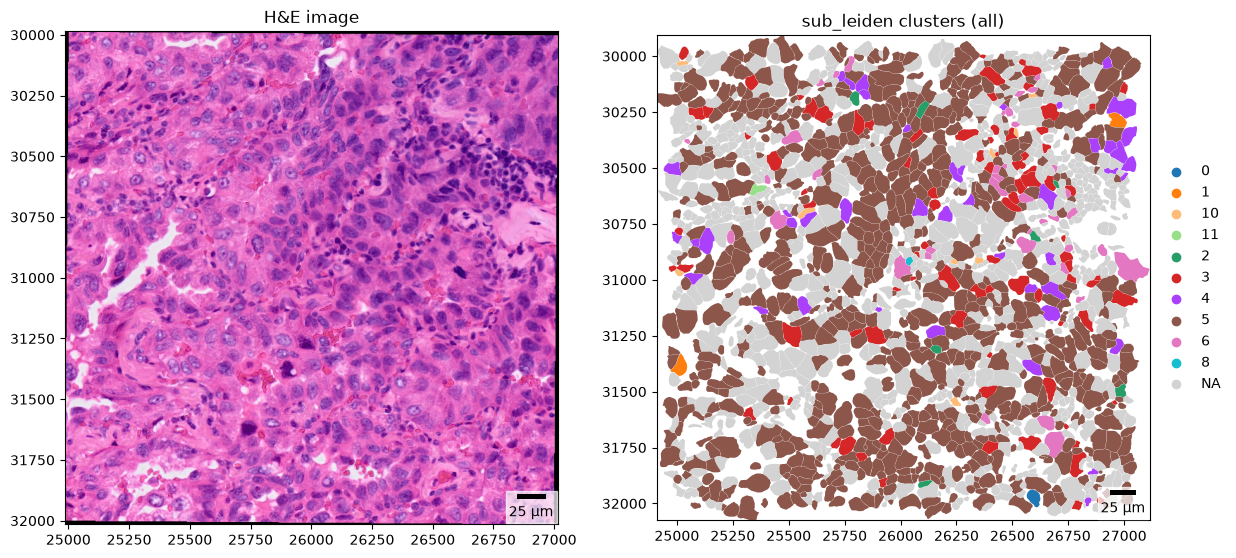

In [38]:
from spatialdata import bounding_box_query
from matplotlib_scalebar.scalebar import ScaleBar

# project all sub_leiden clusters (not just the 0-5 subset) onto the full sdata table
zoom_plot_col = 'sub_leiden_full'
full_table = sdata.tables['table']
full_table.obs[zoom_plot_col] = adata.obs['sub_leiden'].reindex(full_table.obs.index)

# TODO: set to the region of interest (pixel coordinates)
min_x, max_x = 25_000, 27_000
min_y, max_y = 30_000, 32_000

cropped_sdata = bounding_box_query(
    sdata,
    min_coordinate=[min_x, min_y],
    max_coordinate=[max_x, max_y],
    axes=("x", "y"),
    target_coordinate_system="global",
)

axes = plt.subplots(1, 2, figsize=(14, 7))[1].flatten()

cropped_sdata.pl.render_images("he_image").pl.show(ax=axes[0], title="H&E image", coordinate_systems="global")
cropped_sdata.pl.render_shapes("cell_boundaries", color=zoom_plot_col, palette=cluster_colors).pl.show(
    ax=axes[1], title="sub_leiden clusters (all)", coordinate_systems="global"
)

pixel_size_in_microns = 0.2125

for ax in axes:
    scalebar = ScaleBar(
        dx=pixel_size_in_microns,
        units="um",
        location="lower right",
        color="black",
        box_color="white",
        box_alpha=0.7,
        length_fraction=0.1,
    )
    ax.add_artist(scalebar)

## Layer 2 — DEG-driven manual/literature annotation

Compute DEGs per sub-cluster, pull the top 5–10 genes, then cross-check them against literature / [Human Protein Atlas](https://www.proteinatlas.org) to assign a label.

Manual calls are stored in an editable CSV (`layer2_manual_annotation.csv`) so re-running this notebook doesn't wipe out annotation work — edit the CSV directly and re-run the load cell to pick up changes.

In [11]:
sc.tl.rank_genes_groups(adata, groupby='sub_leiden', layer='lognorm', pts=True)

In [12]:
n_top_degs = 10
deg_summary = pd.concat(
    [sc.get.rank_genes_groups_df(adata, group=c).head(n_top_degs).assign(cluster=c) for c in sub_clusters],
    ignore_index=True,
)
deg_summary = deg_summary[['cluster', 'names', 'scores', 'logfoldchanges', 'pvals_adj', 'pct_nz_group', 'pct_nz_reference']]
deg_summary.to_csv(f'{annot_dir}/deg_summary.csv', index=False)
deg_summary.head(10)

,cluster,names,scores,logfoldchanges,pvals_adj,pct_nz_group,pct_nz_reference
0,0,PDXDC1,101.924980,1.517267,0.0,0.929164,0.470900
1,0,IGSF9B,100.672623,3.232784,0.0,0.788860,0.152764
2,0,PABPC1L,93.383125,2.298381,0.0,0.807567,0.203261
3,0,CTTN,84.388283,1.051727,0.0,0.936731,0.562714
4,0,NKX2-1,83.047623,1.005157,0.0,0.967525,0.628805
5,0,HSF4,81.421959,2.453510,0.0,0.692906,0.141752
6,0,CLPTM1L,79.188667,0.903038,0.0,0.979611,0.598907
7,0,TREM1,78.510941,1.716343,0.0,0.821650,0.330268
8,0,CD46,78.424622,0.998720,0.0,0.940200,0.564377
9,0,ITPR3,75.382263,1.310425,0.0,0.878508,0.424135


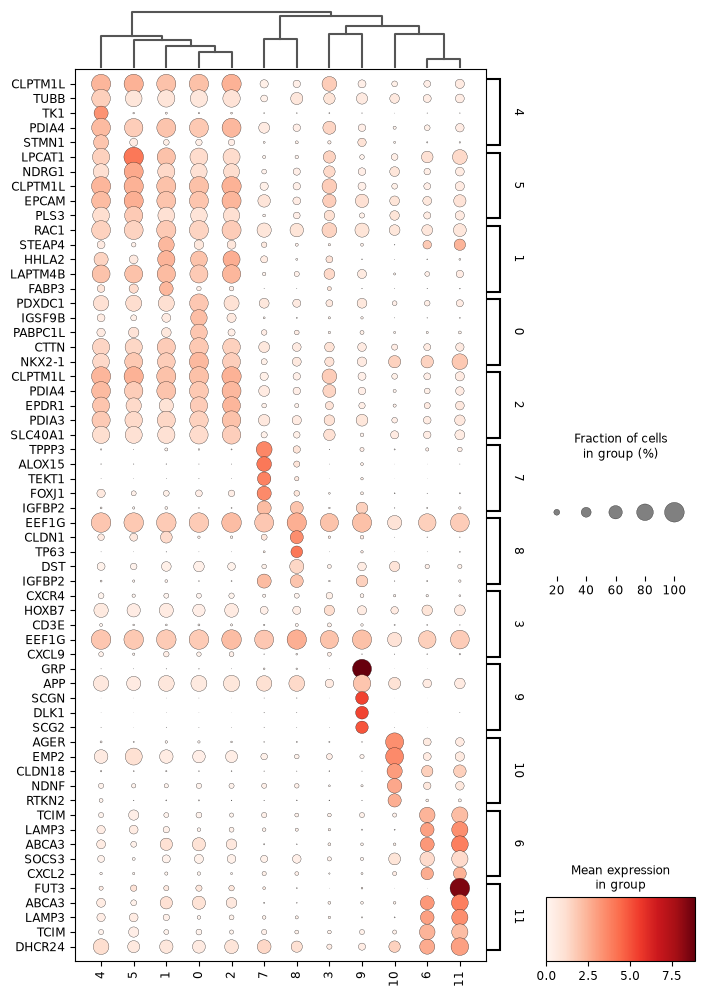

In [15]:
sc.pl.rank_genes_groups_dotplot(adata, n_genes=5, swap_axes=True, figsize=(8, max(12, 0.6 * len(sub_clusters))))

In [16]:
layer2_path = f'{annot_dir}/layer2_manual_annotation.csv'
top_degs_per_cluster = (
    deg_summary.groupby('cluster', observed=True)['names']
    .apply(lambda s: ', '.join(s))
    .reindex(sub_clusters)
)

if os.path.exists(layer2_path):
    layer2_manual_annotation = pd.read_csv(layer2_path, dtype=str).set_index('cluster')
    layer2_manual_annotation['top_degs'] = top_degs_per_cluster
    layer2_manual_annotation = layer2_manual_annotation.reset_index()
else:
    layer2_manual_annotation = pd.DataFrame({
        'cluster': sub_clusters,
        'top_degs': top_degs_per_cluster.values,
        'literature_notes': '',
        'layer2_label': '',
    })

layer2_manual_annotation.to_csv(layer2_path, index=False)
print(f'Edit {layer2_path} to fill in literature_notes / layer2_label, then re-run this cell to reload.')
layer2_manual_annotation

Edit ../../results/xenium_5k/annotation/subclustering/epithelial/layer2_manual_annotation.csv to fill in literature_notes / layer2_label, then re-run this cell to reload.


,cluster,top_degs,literature_notes,layer2_label
0,0,"PDXDC1, IGSF9B, PABPC1L, CTTN, NKX2-1, HSF4, C...",,
1,1,"RAC1, STEAP4, HHLA2, LAPTM4B, FABP3, LDHA, CLP...",,
2,2,"CLPTM1L, PDIA4, EPDR1, PDIA3, SLC40A1, LAPTM4B...",,
3,3,"CXCR4, HOXB7, CD3E, EEF1G, CXCL9, IKZF1, RAC1,...",,
4,4,"CLPTM1L, TUBB, TK1, PDIA4, STMN1, TOP2A, CTSH,...",,
5,5,"LPCAT1, NDRG1, CLPTM1L, EPCAM, PLS3, CDH1, SDH...",,
6,6,"TCIM, LAMP3, ABCA3, SOCS3, CXCL2, NR4A1, EPAS1...",,
7,7,"TPPP3, ALOX15, TEKT1, FOXJ1, IGFBP2, PROM1, SP...",,
8,8,"EEF1G, CLDN1, TP63, DST, IGFBP2, HNRNPA1L2, IT...",,
9,9,"GRP, APP, SCGN, DLK1, SCG2, MEG3, RPRM, ASCL1,...",,


#### Cross-check top DEGs against HPA marker genes

Fisher's exact test (via `celltypegenomics`) of each sub-cluster's top DEGs against Human Protein Atlas cell-type marker gene sets, as an additional cross-check for the manual calls above.

In [17]:
from celltypegenomics import celltypefishertest

symbol_to_ensembl = adata.var['gene_ids'].to_dict()


def hpa_fisher_test(cluster, n=n_top_degs):
    genes = deg_summary.loc[deg_summary['cluster'] == cluster, 'names'].head(n)
    ensembl_ids = [symbol_to_ensembl[g] for g in genes if g in symbol_to_ensembl]
    result = celltypefishertest(ensembl_ids, hpa_marker_genes=True)
    return result.sort_values('adjusted_p_value').assign(cluster=cluster)


hpa_annotation = pd.concat([hpa_fisher_test(c) for c in sub_clusters], ignore_index=False)
hpa_annotation.to_csv(f'{annot_dir}/layer2_hpa_fishertest.csv')
hpa_annotation.groupby('cluster').head(3)

,p_value,odds_ratio,count_in_both,count_in_genelist_not_cell_type,count_in_cell_type_not_genelist,count_in_neither,adjusted_p_value,cluster


In [18]:
hpa_best_per_cluster = (
    hpa_annotation.reset_index(names='cell_type')
    .sort_values('adjusted_p_value')
    .groupby('cluster', sort=False)
    .first()
    .reindex(sub_clusters)[['cell_type', 'adjusted_p_value', 'odds_ratio']]
)
hpa_best_per_cluster

,cell_type,adjusted_p_value,odds_ratio
cluster,,,
0,NaN,NaN,NaN
1,NaN,NaN,NaN
2,NaN,NaN,NaN
3,NaN,NaN,NaN
4,NaN,NaN,NaN
5,NaN,NaN,NaN
6,NaN,NaN,NaN
7,NaN,NaN,NaN
8,NaN,NaN,NaN


## Layer 3 — Functional enrichment (GO / KEGG / Reactome)

Over-representation analysis (Enrichr) on the top DEGs of each sub-cluster, to support/refine the cell type call with pathway-level evidence.

In [19]:
gene_sets = ['GO_Biological_Process_2023', 'KEGG_2021_Human', 'Reactome_2022']
n_genes_enrichment = 50


def top_deg_genes(cluster, n=n_genes_enrichment, padj_thresh=0.05):
    df = sc.get.rank_genes_groups_df(adata, group=cluster)
    df = df[(df['pvals_adj'] < padj_thresh) & (df['logfoldchanges'] > 0)]
    return df.sort_values('scores', ascending=False)['names'].head(n).tolist()


def run_enrichment(gene_list, cluster, gene_sets=gene_sets):
    if len(gene_list) == 0:
        return pd.DataFrame()
    try:
        enr = gp.enrich_multi(gene_list=gene_list, gene_sets=gene_sets, organism='human', outdir=None)
    except AttributeError:
        # older/newer gseapy versions expose enrichr per-library instead of enrich_multi
        enr = pd.concat(
            [gp.enrichr(gene_list=gene_list, gene_sets=[gs], organism='human', outdir=None).results.assign(Gene_set=gs)
             for gs in gene_sets],
            ignore_index=True,
        )
    enr = enr.results if hasattr(enr, 'results') else enr
    enr['cluster'] = cluster
    return enr

In [20]:
%%time
enrichment_results = {}
for c in sub_clusters:
    genes = top_deg_genes(c)
    res = run_enrichment(genes, c)
    if not res.empty:
        enrichment_results[c] = res

layer3_enrichment = pd.concat(enrichment_results.values(), ignore_index=True) if enrichment_results else pd.DataFrame()
layer3_enrichment.to_csv(f'{annot_dir}/layer3_functional_enrichment.csv', index=False)
layer3_enrichment.head(10)

CPU times: user 2.39 s, sys: 56.8 ms, total: 2.45 s
Wall time: 1min 14s


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes,cluster
0,GO_Biological_Process_2023,Phosphatidylcholine Biosynthetic Process (GO:0...,2/19,0.001019,0.131702,0,0,48.855392,336.546738,MUC1;CHKA,0
1,GO_Biological_Process_2023,RNA Processing (GO:0006396),4/183,0.001125,0.131702,0,0,9.604566,65.217019,SFPQ;HNRNPH1;PABPC4;PRPF3,0
2,GO_Biological_Process_2023,Regulation Of Regulatory T Cell Differentiatio...,2/22,0.001370,0.131702,0,0,41.520833,273.732925,KAT2A;CD46,0
3,GO_Biological_Process_2023,Glycerophospholipid Biosynthetic Process (GO:0...,3/108,0.002496,0.131702,0,0,12.063830,72.300092,MUC1;CHKA;INPPL1,0
4,GO_Biological_Process_2023,Positive Regulation Of Multicellular Organisma...,5/387,0.002741,0.131702,0,0,5.691681,33.578255,KAT2A;MUC1;NUMA1;HHLA2;PRKCA,0
5,GO_Biological_Process_2023,"DNA Damage Response, Signal Transduction By P5...",2/36,0.003655,0.131702,0,0,24.406863,136.963492,MUC1;MYO6,0
6,GO_Biological_Process_2023,Negative Regulation Of Organelle Assembly (GO:...,2/36,0.003655,0.131702,0,0,24.406863,136.963492,KAT2A;CDK10,0
7,GO_Biological_Process_2023,Regulation Of Gene Expression (GO:0010468),8/1127,0.006449,0.131702,0,0,3.205413,16.167748,NOTCH2;KAT2A;SFPQ;HNRNPH1;HHLA2;NKX2-1;DIP2A;CD46,0
8,GO_Biological_Process_2023,Negative Regulation Of Apoptotic Process (GO:0...,5/482,0.006917,0.131702,0,0,4.535989,22.561098,NOTCH2;SHC1;VSTM2L;PRKCA;MAPK8IP3,0
9,GO_Biological_Process_2023,Protein Transport (GO:0015031),4/313,0.007699,0.131702,0,0,5.527227,26.899154,CTTN;MYO6;SEPTIN9;PDIA4,0


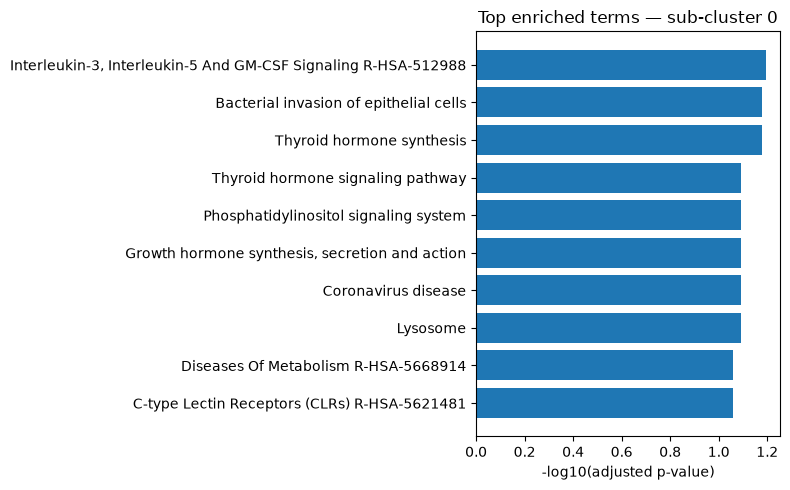

In [21]:
# Barplot of the top enriched terms for a single sub-cluster (edit cluster id as needed)
cluster_to_plot = sub_clusters[0]
top_terms = (
    layer3_enrichment[layer3_enrichment['cluster'] == cluster_to_plot]
    .sort_values('Adjusted P-value')
    .head(10)
)
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top_terms['Term'], -np.log10(top_terms['Adjusted P-value']))
ax.invert_yaxis()
ax.set_xlabel('-log10(adjusted p-value)')
ax.set_title(f'Top enriched terms — sub-cluster {cluster_to_plot}')
plt.tight_layout()

In [22]:
top_enriched_terms_per_cluster = (
    layer3_enrichment.sort_values('Adjusted P-value')
    .groupby('cluster', observed=True)['Term']
    .apply(lambda s: '; '.join(s.head(3)))
    .reindex(sub_clusters)
)

## Consolidation

Merge all three layers into one summary table per sub-cluster.

In [23]:
n_cells_per_cluster = adata.obs['sub_leiden'].value_counts().reindex(sub_clusters)

subcluster_annotation_summary = (
    layer1_annotation.set_index('cluster')
    .join(layer2_manual_annotation.set_index('cluster'))
    .assign(
        n_cells=n_cells_per_cluster,
        top_enriched_terms=top_enriched_terms_per_cluster,
    )
    .reset_index()
)
subcluster_annotation_summary.to_csv(f'{annot_dir}/subcluster_annotation_summary.csv', index=False)
subcluster_annotation_summary

,cluster,canonical_label,canonical_score,top_degs,literature_notes,layer2_label,n_cells,top_enriched_terms
0,0,Epithelial_LUAD (Adenocarcinoma),0.111937,"PDXDC1, IGSF9B, PABPC1L, CTTN, NKX2-1, HSF4, C...",,,9515,"Interleukin-3, Interleukin-5 And GM-CSF Signal..."
1,1,Epithelial_LUAD (Adenocarcinoma),0.034582,"RAC1, STEAP4, HHLA2, LAPTM4B, FABP3, LDHA, CLP...",,,2448,Hepatitis C; Pathogenic Escherichia coli infec...
2,2,Epithelial_Tumor_Malignant,0.057090,"CLPTM1L, PDIA4, EPDR1, PDIA3, SLC40A1, LAPTM4B...",,,13696,Lysosome; Immune System R-HSA-168256; Neutroph...
3,3,Proliferating,-0.001414,"CXCR4, HOXB7, CD3E, EEF1G, CXCL9, IKZF1, RAC1,...",,,2247,Immune System R-HSA-168256; Adaptive Immune Sy...
4,4,Proliferating,0.109205,"CLPTM1L, TUBB, TK1, PDIA4, STMN1, TOP2A, CTSH,...",,,2660,"Cell Cycle, Mitotic R-HSA-69278; Cell Cycle R-..."
5,5,Epithelial_Tumor_Malignant,0.105468,"LPCAT1, NDRG1, CLPTM1L, EPCAM, PLS3, CDH1, SDH...",,,8030,Protein Targeting To Vacuole Involved In Autop...
6,6,Epithelial_AT2,0.591675,"TCIM, LAMP3, ABCA3, SOCS3, CXCL2, NR4A1, EPAS1...",,,8454,Signaling By Non-Receptor Tyrosine Kinases R-H...
7,7,Epithelial_Airway_Club_Secretory,0.613782,"TPPP3, ALOX15, TEKT1, FOXJ1, IGFBP2, PROM1, SP...",,,8261,Cilium Movement (GO:0003341); Cilium Assembly ...
8,8,Epithelial_Airway_Ciliated,0.044859,"EEF1G, CLDN1, TP63, DST, IGFBP2, HNRNPA1L2, IT...",,,2722,Positive Regulation Of Transcription By RNA Po...
9,9,Epithelial_Airway_Club_Secretory,0.218664,"GRP, APP, SCGN, DLK1, SCG2, MEG3, RPRM, ASCL1,...",,,1129,Serotonergic synapse; Metabolism Of Amine-Deri...


Fill in `subcluster_labels` below once the layer 1-3 evidence above has been reviewed, then re-run the remaining cells to plot the final sub-type calls (in-memory only — this notebook does not persist a new zarr store).

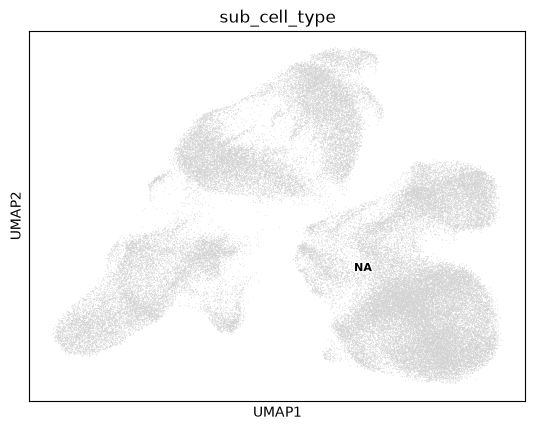

In [24]:
# TODO: fill in final sub-type labels per sub_leiden cluster, informed by layers 1-3 above
subcluster_labels = {
    # 'Epithelial_AT2': ['0'],
}

cluster_to_label = {c: label for label, cs in subcluster_labels.items() for c in cs}
adata.obs['sub_cell_type'] = adata.obs['sub_leiden'].map(cluster_to_label).astype('category')

sc.pl.umap(adata, color='sub_cell_type', legend_loc='on data', legend_fontsize=8, legend_fontoutline=2)

WARNING  render_shapes: Column 'sub_cell_type' for element 'cell_boundaries' contains only NaN values; rendering   
         with na_color.                                                                                            


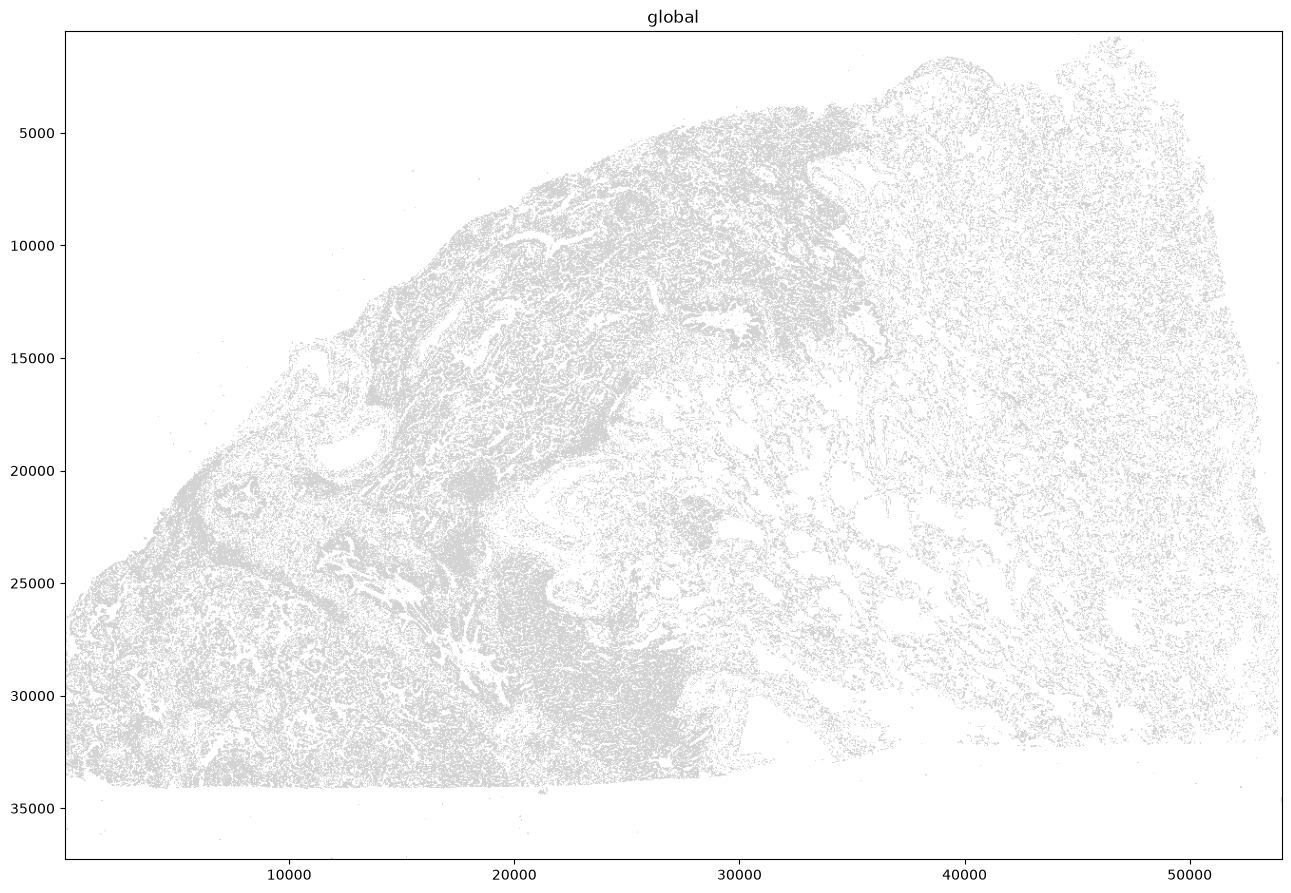

In [ ]:
plot_col = 'sub_cell_type'
full_table = sdata.tables['table']
full_table.obs[plot_col] = adata.obs[plot_col].reindex(full_table.obs.index)

sdata.tables['table'].obs['region'] = 'cell_boundaries'
sdata.set_table_annotates_spatialelement('table', region='cell_boundaries')
sdata.pl.render_shapes('cell_boundaries', color=plot_col).pl.show(figsize=(12.8, 9.6))


In [39]:
# lightweight cell_id + sub-cluster export for napari (re-run after filling in subcluster_labels)
export_path = f'{annot_dir}/sub_cluster_labels.csv'
export_df = adata.obs[['cell_id', 'sub_leiden', 'sub_cell_type']].copy()
export_df.to_csv(export_path, index=False)
print(f'Saved {len(export_df)} cells -> {export_path}')

Saved 68449 cells -> ../../results/xenium_5k/annotation/subclustering/epithelial/sub_cluster_labels.csv
